In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set_theme()
gc.enable()

# Aggregating Bureau Balance

In [2]:
bureau_balance=pd.read_csv('bureau_balance.csv')
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [3]:
bureau_balance.shape

(27299925, 3)

In [4]:
bureau_balance['STATUS'].unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

In [5]:
bureau_balance_agg=bureau_balance[['SK_ID_BUREAU', 'STATUS']].value_counts().unstack().replace(np.nan, 0).reset_index()
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,0,1,2,3,4,5,C,X
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0


In [6]:
bureau_balance_agg['TOTAL']=bureau_balance_agg.drop('SK_ID_BUREAU', axis=1).sum(axis=1)
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,0,1,2,3,4,5,C,X,TOTAL
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,97.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,83.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0


In [7]:
bureau_balance_agg.rename(columns={'0': 'STATUS_NO_DPD', '1': 'STATUS_<31DPD', '2': 'STATUS_<61DPD', '3': 'STATUS_<91DPD', 
                                   '4': 'STATUS_<121DPD', '5': 'STATUS_>120DPD',
                                   'C': 'STATUS_CLOSED', 'X': 'STATUS_NA', 'TOTAL': 'STATUS_TOTAL'}, inplace=True)
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,97.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,83.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0


# Dealing with main Bureau data

In [8]:
del bureau_balance
bureau=pd.read_csv('bureau.csv')
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


#### Merging with aggregated bureau balance data

In [9]:
bureau['SK_ID_BUREAU'].unique().shape, bureau_balance_agg['SK_ID_BUREAU'].unique().shape

((1716428,), (817395,))

In [10]:
combined_data=pd.merge(left=bureau, right=bureau_balance_agg, how='left', on='SK_ID_BUREAU')
combined_data.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_ANNUITY,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
numerical_features=combined_data.select_dtypes(exclude='object').columns
categorical_features=combined_data.columns.difference(numerical_features)

## Numerical Features

In [12]:
numerical_frame=combined_data[numerical_features].copy()
numerical_frame.head()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,...,AMT_ANNUITY,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,215354,5714462,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,-203,0,528.0,NaN,NaN,0,464323.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,-203,0,NaN,NaN,NaN,0,90000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
numerical_frame['SK_ID_CURR'].unique().shape

(305811,)

In [14]:
numerical_frame.replace(to_replace={'STATUS_NO_DPD': np.nan, 'STATUS_<31DPD': np.nan, 'STATUS_<61DPD': np.nan,'STATUS_<91DPD': np.nan,        
                                    'STATUS_<121DPD': np.nan, 'STATUS_>120DPD': np.nan, 'STATUS_CLOSED': np.nan, 'STATUS_NA': np.nan,           
                                    'STATUS_TOTAL': np.nan}, value=0, inplace=True)
numerical_frame.isnull().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
STATUS_NO_DPD                   0
STATUS_<31DPD                   0
STATUS_<61DPD                   0
STATUS_<91DPD                   0
STATUS_<121DPD                  0
STATUS_>120DPD                  0
STATUS_CLOSED                   0
STATUS_NA                       0
STATUS_TOTAL                    0
dtype: int64

### Agregating numerical data

In [15]:
bureau_agg=numerical_frame.groupby(by='SK_ID_CURR').agg(func=['count', 'min', 'max', 'median'])
cols=pd.Index(['_'.join(val) for val in bureau_agg.columns.to_flat_index()])
bureau_agg.columns=cols
bureau_agg.shape

(305811, 88)

In [16]:
drop_cols=['_'.join([val, 'count']) for val in numerical_frame.columns.difference(['SK_ID_CURR', 'SK_ID_BUREAU'])]
drop_cols+=['SK_ID_BUREAU_min', 'SK_ID_BUREAU_max', 'SK_ID_BUREAU_median']

bureau_agg.drop(labels=drop_cols, axis=1, inplace=True)
bureau_agg.reset_index(inplace=True)
bureau_agg.shape

(305811, 65)

In [17]:
main_data_id_target=pd.read_csv('application_train.csv', usecols=['SK_ID_CURR', 'TARGET'])
main_data_id_target.head()

,SK_ID_CURR,TARGET
0,100002,1
1,100003,0
2,100004,0
3,100006,0
4,100007,0


#### Combining target to bureau agg

In [18]:
bureau_agg_target=pd.merge(left=bureau_agg, right=main_data_id_target, on='SK_ID_CURR', how='inner')
bureau_agg_target.shape

(263491, 66)

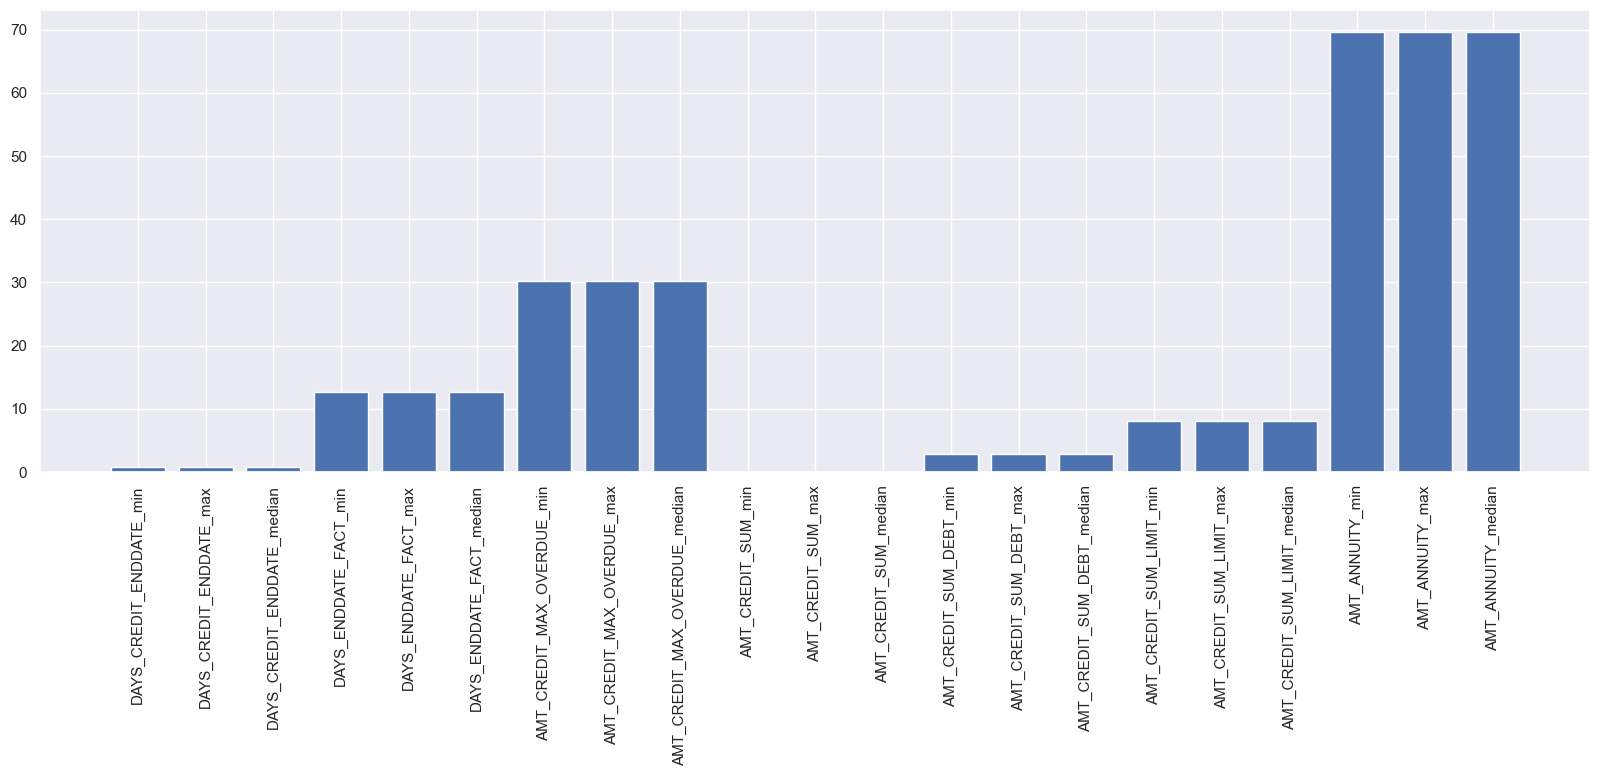

In [19]:
plot_data=bureau_agg_target.isnull().sum()*100/bureau_agg_target.shape[0]
plot_data=plot_data[plot_data>0]
ax=plt.axes()
ax.bar(plot_data.index, plot_data.values)
ax.tick_params(axis='x', rotation=90)
ax.get_figure().set_size_inches(20, 6)

### Functions

In [20]:
def plot_hist_box(data, feature):
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [21]:
def plot_hist_default_pct(feature, dataframe, bins):
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [22]:
def calc_iqr(feature, data):
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [23]:
def plot_kde_vs_target(feature, main_data):
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [24]:
def plot_all_numeric_kde(main_data, numerical_features):
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [25]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [26]:
def median_vs_target(feature, data):
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [27]:
# plot_all_numeric_kde(bureau_agg_target, bureau_agg_target.columns)

In [30]:
# # del bureau
# # del bureau_agg
# del bureau_balance_agg
# gc.collect()

45

In [31]:
numerical_features=pd.Index(['DAYS_CREDIT_min', 'DAYS_CREDIT_max', 'DAYS_CREDIT_median',
                             'DAYS_CREDIT_ENDDATE_min', 'DAYS_CREDIT_ENDDATE_max', 'DAYS_CREDIT_ENDDATE_median',
                             'DAYS_ENDDATE_FACT_min', 'DAYS_ENDDATE_FACT_median', 'DAYS_CREDIT_UPDATE_min',
                             'DAYS_CREDIT_UPDATE_median', 'SK_ID_CURR', 'TARGET'])
numerical_frame=bureau_agg_target[numerical_features].copy()

### DAYS_CREDIT_min

In [32]:
numerical_frame['DAYS_CREDIT_min'].isnull().sum()

0

In [33]:
numerical_frame['DAYS_CREDIT_min'].describe()

count    263491.000000
mean      -1762.374882
std         863.862181
min       -2922.000000
25%       -2583.000000
50%       -1827.000000
75%       -1035.000000
max           0.000000
Name: DAYS_CREDIT_min, dtype: float64

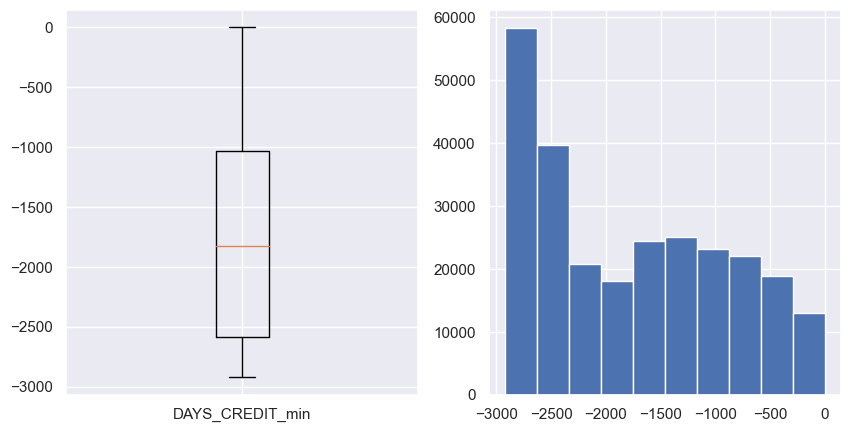

In [34]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_min');

Median of DAYS_CREDIT_min with target=0 : -1861.000000
Median of DAYS_CREDIT_min with target=1 : -1469.000000


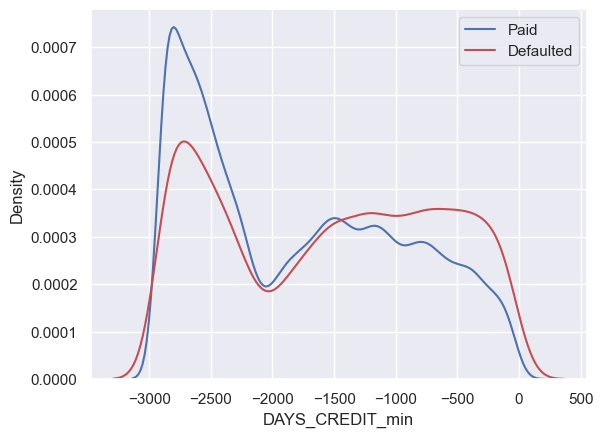

In [36]:
plot_kde_vs_target('DAYS_CREDIT_min', numerical_frame)
median_vs_target('DAYS_CREDIT_min', numerical_frame)

Median of YEARS_CREDIT_min with target=0 : 5.098630
Median of YEARS_CREDIT_min with target=1 : 4.024658


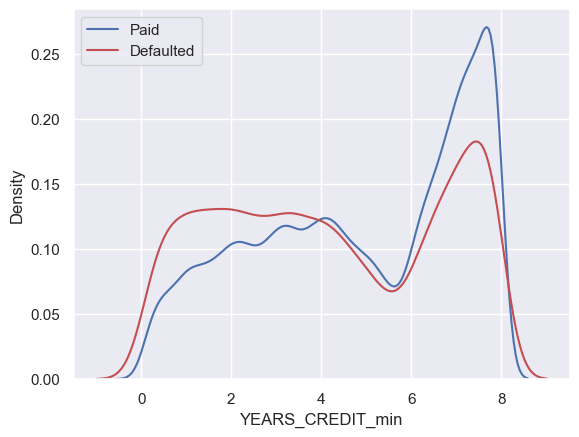

In [39]:
numerical_frame['YEARS_CREDIT_min']=numerical_frame['DAYS_CREDIT_min']/-365
plot_kde_vs_target('YEARS_CREDIT_min', numerical_frame)
median_vs_target('YEARS_CREDIT_min', numerical_frame)

(-0.001, 1.493]    12.368565
(1.493, 2.57]       9.703375
(2.57, 3.542]       8.628765
(3.542, 4.463]      7.755325
(4.463, 5.712]      6.977301
(5.712, 6.655]      6.442052
(6.655, 7.2]        6.044332
(7.2, 7.652]        5.932232
(7.652, 8.005]      5.708911
Name: YEARS_CREDIT_min_binned, dtype: float64


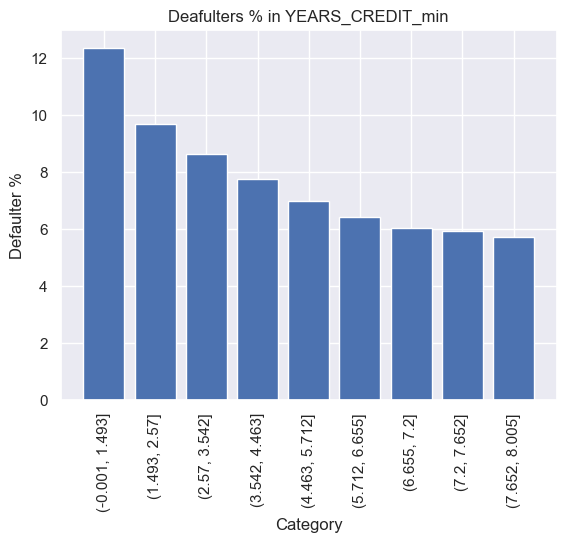

In [40]:
plot_hist_default_pct('YEARS_CREDIT_min', numerical_frame, 9)

### DAYS_CREDIT_max

In [41]:
numerical_frame['DAYS_CREDIT_max'].isnull().sum()

0

In [42]:
numerical_frame['DAYS_CREDIT_max'].describe()

count    263491.000000
mean       -489.297817
std         537.574145
min       -2922.000000
25%        -620.000000
50%        -300.000000
75%        -143.000000
max           0.000000
Name: DAYS_CREDIT_max, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

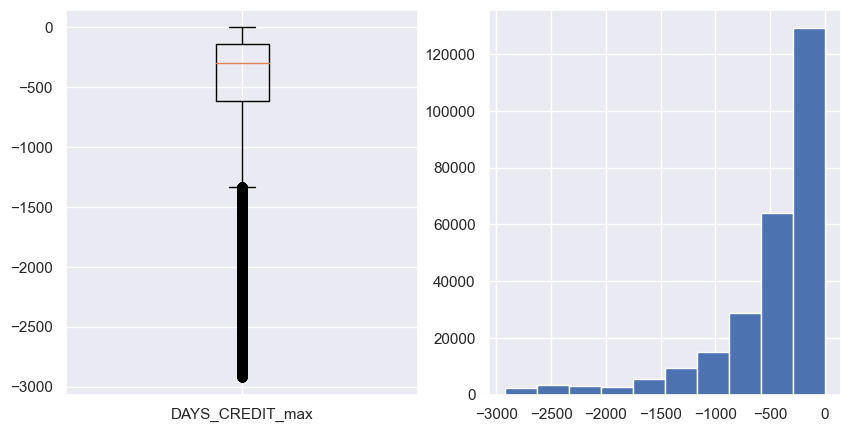

In [44]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_max')

Median of DAYS_CREDIT_max with target=0 : -308.000000
Median of DAYS_CREDIT_max with target=1 : -221.000000


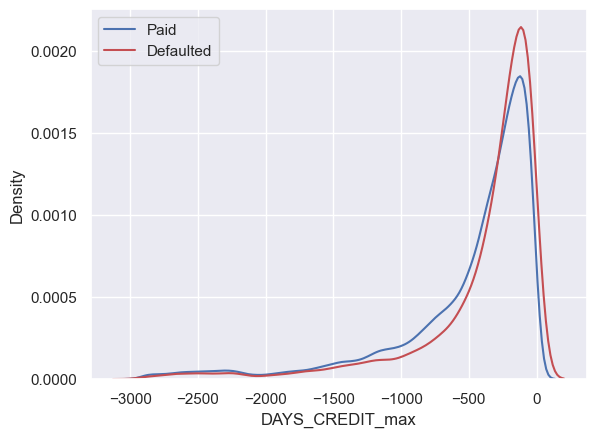

In [46]:
plot_kde_vs_target('DAYS_CREDIT_max', numerical_frame)
median_vs_target('DAYS_CREDIT_max', numerical_frame)

Median of YEARS_CREDIT_max with target=0 : 0.843836
Median of YEARS_CREDIT_max with target=1 : 0.605479


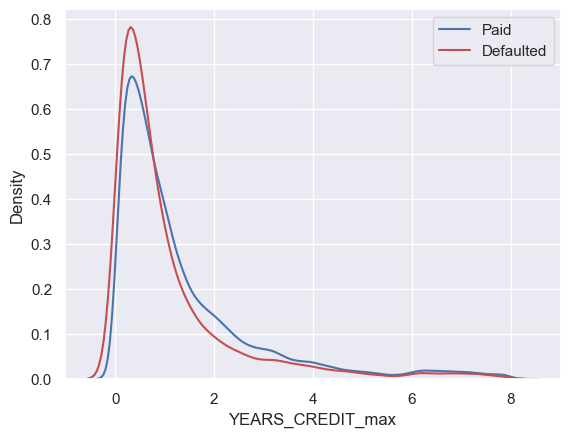

In [47]:
numerical_frame['YEARS_CREDIT_max']=numerical_frame['DAYS_CREDIT_max']/-365
plot_kde_vs_target('YEARS_CREDIT_max', numerical_frame)
median_vs_target('YEARS_CREDIT_max', numerical_frame)

(-0.001, 0.2]     12.237372
(0.2, 0.351]       9.380792
(0.351, 0.518]     8.784495
(0.518, 0.71]      8.470588
(0.71, 0.953]      7.186455
(0.953, 1.29]      6.350838
(1.29, 1.879]      5.983227
(1.879, 3.033]     5.171825
(3.033, 8.005]     5.952218
Name: YEARS_CREDIT_max_binned, dtype: float64


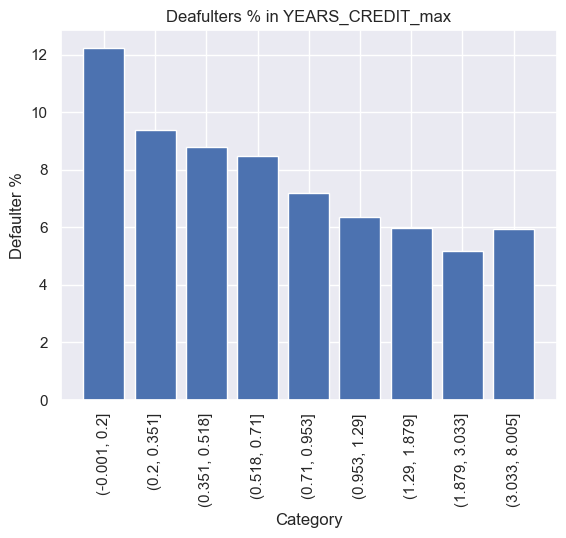

In [48]:
plot_hist_default_pct('YEARS_CREDIT_max', numerical_frame, 9)

### DAYS_CREDIT_median

In [49]:
numerical_frame['DAYS_CREDIT_median'].isnull().sum()

0

In [50]:
numerical_frame['DAYS_CREDIT_median'].describe()

count    263491.000000
mean      -1049.644056
std         625.841540
min       -2922.000000
25%       -1418.000000
50%        -958.000000
75%        -567.500000
max           0.000000
Name: DAYS_CREDIT_median, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

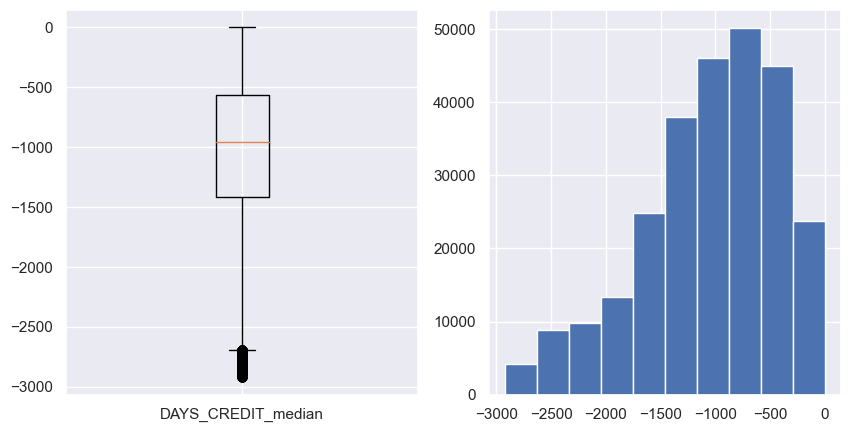

In [51]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_median')

Median of DAYS_CREDIT_median with target=0 : -976.000000
Median of DAYS_CREDIT_median with target=1 : -729.000000


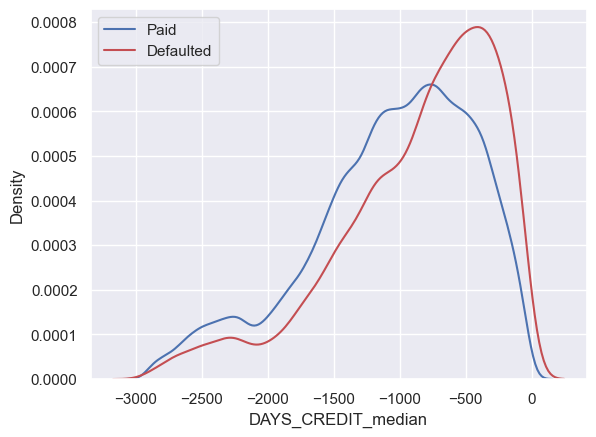

In [52]:
plot_kde_vs_target('DAYS_CREDIT_median', numerical_frame)
median_vs_target('DAYS_CREDIT_median', numerical_frame)

Median of YEARS_CREDIT_median with target=0 : 2.673973
Median of YEARS_CREDIT_median with target=1 : 1.997260


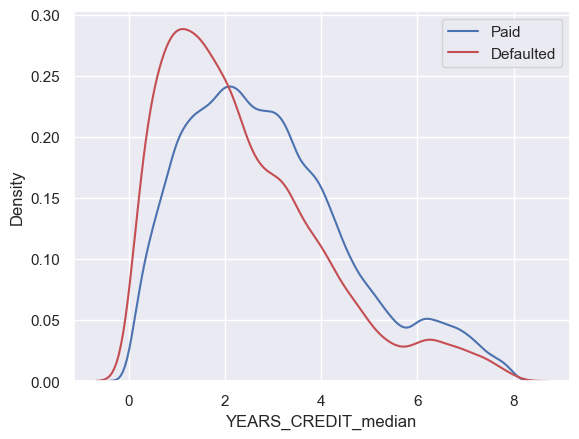

In [53]:
numerical_frame['YEARS_CREDIT_median']=numerical_frame['DAYS_CREDIT_median']/-365
plot_kde_vs_target('YEARS_CREDIT_median', numerical_frame)
median_vs_target('YEARS_CREDIT_median', numerical_frame)

(-0.001, 0.918]    13.843482
(0.918, 1.43]      10.354513
(1.43, 1.915]       9.083779
(1.915, 2.375]      7.690996
(2.375, 2.879]      6.259187
(2.879, 3.404]      6.102692
(3.404, 4.06]       5.736196
(4.06, 5.142]       5.362344
(5.142, 8.005]      5.117169
Name: YEARS_CREDIT_median_binned, dtype: float64


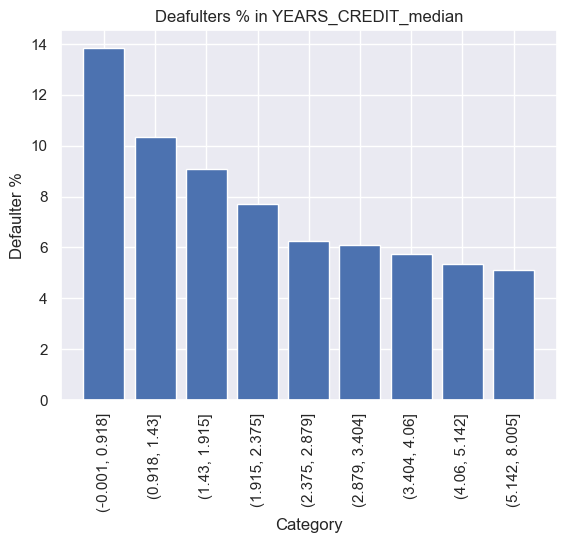

In [54]:
plot_hist_default_pct('YEARS_CREDIT_median', numerical_frame, 9)

### DAYS_CREDIT_ENDDATE_min

In [55]:
numerical_frame['DAYS_CREDIT_ENDDATE_min'].isnull().sum()

2249

In [56]:
numerical_frame['DAYS_CREDIT_ENDDATE_min'].describe()

count    261242.000000
mean      -1029.578131
std        2640.338801
min      -42060.000000
25%       -2132.000000
50%       -1268.000000
75%        -449.000000
max       31198.000000
Name: DAYS_CREDIT_ENDDATE_min, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

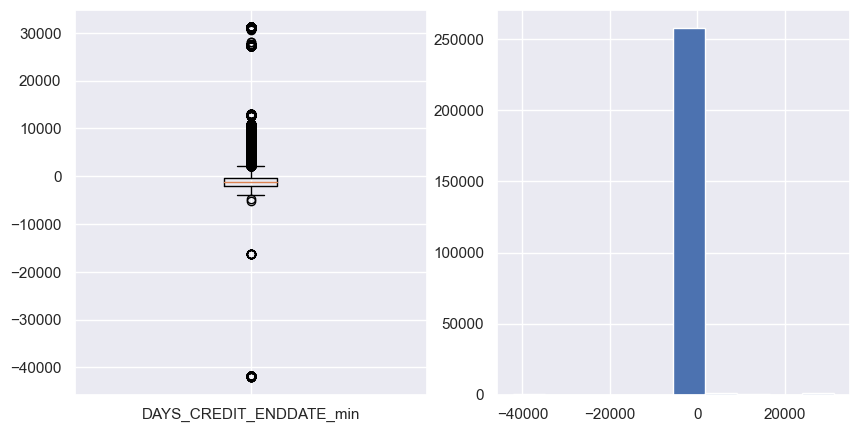

In [57]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_ENDDATE_min')

Number of outliers : 1954


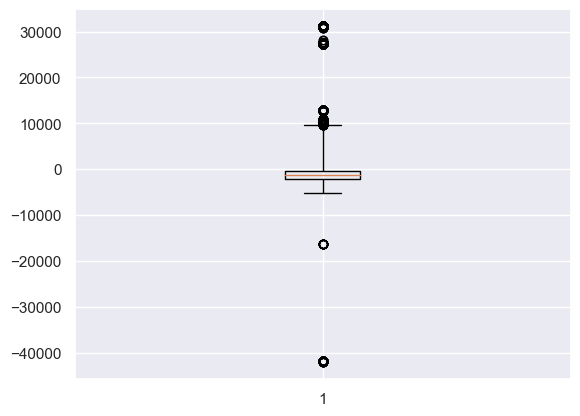

In [77]:
plt.boxplot(numerical_frame['DAYS_CREDIT_ENDDATE_min'].dropna(), whis=6);
numerical_frame['YEARS_CREDIT_ENDDATE_min']=numerical_frame['DAYS_CREDIT_ENDDATE_min']/365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_ENDDATE_min', numerical_frame)
numerical_frame['DAYS_CREDIT_ENDDATE_min_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_ENDDATE_min']<q1-6*iqr) | 
                    (numerical_frame['DAYS_CREDIT_ENDDATE_min']>q3+6*iqr), 'DAYS_CREDIT_ENDDATE_min_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_ENDDATE_min_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_ENDDATE_min_outlier']==1).sum()))

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

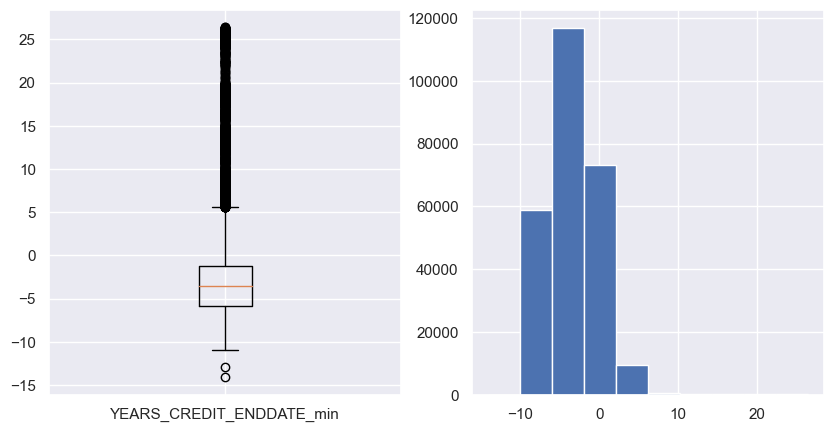

In [78]:
plot_hist_box(good_frame, 'YEARS_CREDIT_ENDDATE_min')

Median of YEARS_CREDIT_ENDDATE_min with target=0 : -3.569863
Median of YEARS_CREDIT_ENDDATE_min with target=1 : -2.668493


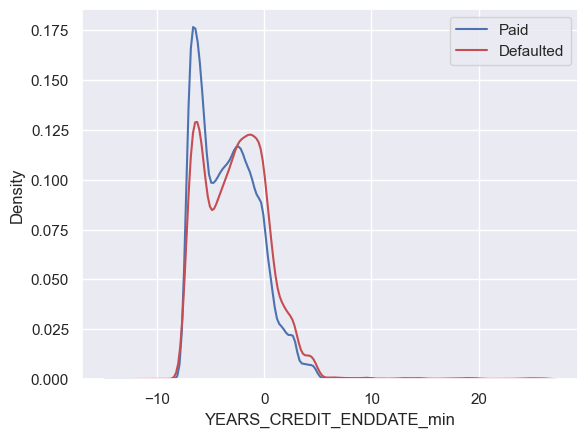

In [79]:
plot_kde_vs_target('YEARS_CREDIT_ENDDATE_min', good_frame)
median_vs_target('YEARS_CREDIT_ENDDATE_min', good_frame)

(-14.110999999999999, -6.679]     5.653306
(-6.679, -6.03]                   6.064176
(-6.03, -5.164]                   6.296862
(-5.164, -4.027]                  6.748743
(-4.027, -2.989]                  7.201889
(-2.989, -2.041]                  7.822881
(-2.041, -1.008]                  8.694898
(-1.008, 0.228]                  10.020151
(0.228, 26.422]                  10.586602
Name: YEARS_CREDIT_ENDDATE_min_binned, dtype: float64


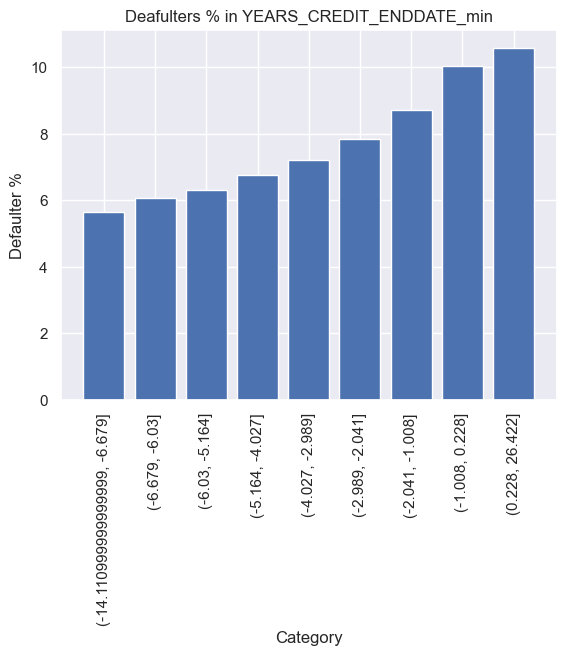

In [80]:
plot_hist_default_pct('YEARS_CREDIT_ENDDATE_min', good_frame, 9)

### DAYS_CREDIT_ENDDATE_max

In [81]:
numerical_frame['DAYS_CREDIT_ENDDATE_max'].isnull().sum()

2249

In [82]:
numerical_frame['DAYS_CREDIT_ENDDATE_max'].describe()

count    261242.000000
mean       4433.041953
std        9350.942497
min      -41875.000000
25%         125.000000
50%         909.000000
75%        1683.000000
max       31199.000000
Name: DAYS_CREDIT_ENDDATE_max, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

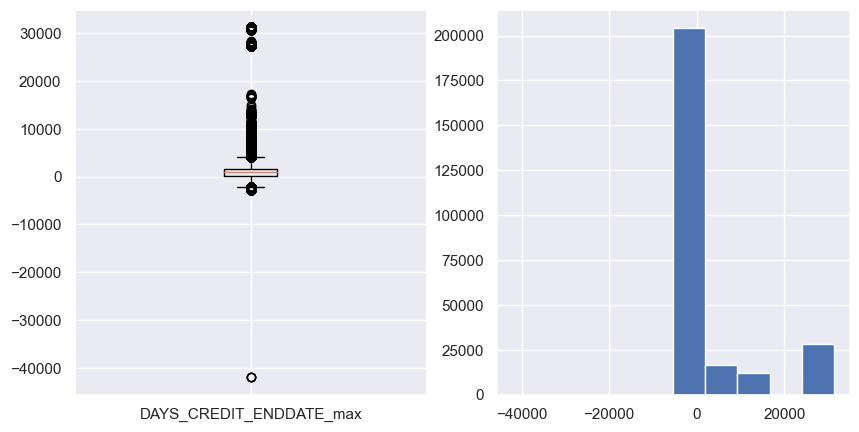

In [83]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_ENDDATE_max')

Number of outliers : 30571


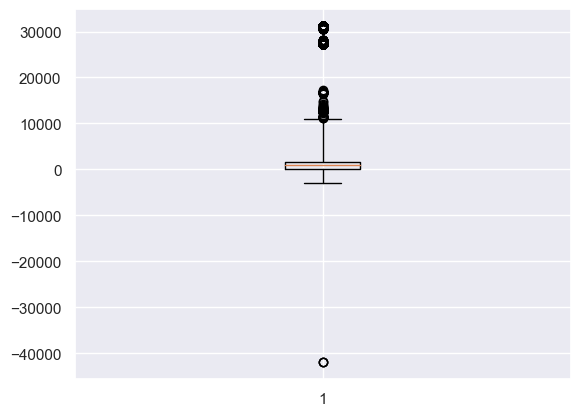

In [85]:
plt.boxplot(numerical_frame['DAYS_CREDIT_ENDDATE_max'].dropna(), whis=6);
numerical_frame['YEARS_CREDIT_ENDDATE_max']=numerical_frame['DAYS_CREDIT_ENDDATE_max']/365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_ENDDATE_max', numerical_frame)
numerical_frame['DAYS_CREDIT_ENDDATE_max_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_ENDDATE_max']<q1-6*iqr) | 
                    (numerical_frame['DAYS_CREDIT_ENDDATE_max']>q3+6*iqr), 'DAYS_CREDIT_ENDDATE_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_ENDDATE_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_ENDDATE_max_outlier']==1).sum()))

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

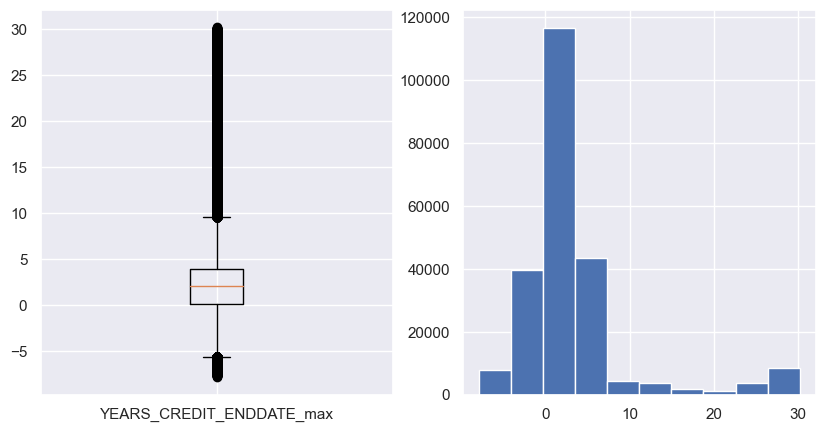

In [86]:
plot_hist_box(good_frame, 'YEARS_CREDIT_ENDDATE_max')

Median of YEARS_CREDIT_ENDDATE_max with target=0 : 1.989041
Median of YEARS_CREDIT_ENDDATE_max with target=1 : 2.438356


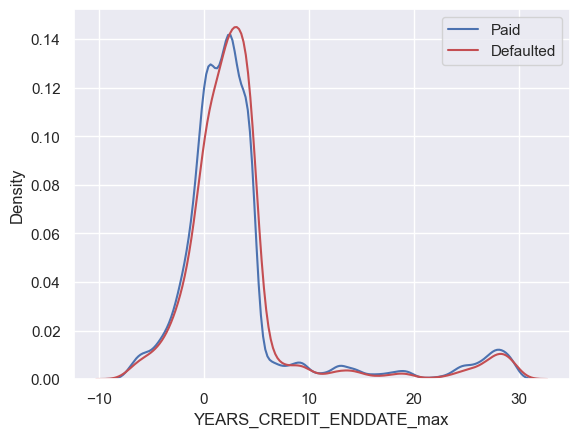

In [87]:
plot_kde_vs_target('YEARS_CREDIT_ENDDATE_max', good_frame)
median_vs_target('YEARS_CREDIT_ENDDATE_max', good_frame)

(-7.831, -1.523]      6.360162
(-1.523, -0.0986]     5.807283
(-0.0986, 0.696]      6.628567
(0.696, 1.622]        6.939015
(1.622, 2.425]        7.127825
(2.425, 3.107]        8.106523
(3.107, 4.104]        8.499201
(4.104, 5.926]       10.190435
(5.926, 30.178]       6.462691
Name: YEARS_CREDIT_ENDDATE_max_binned, dtype: float64


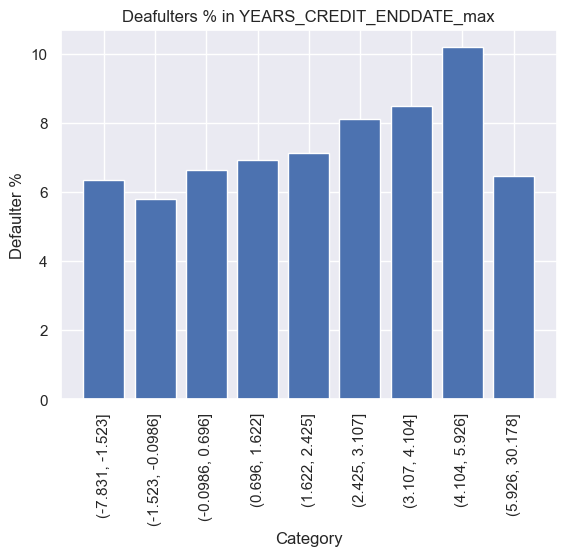

In [91]:
plot_hist_default_pct('YEARS_CREDIT_ENDDATE_max', good_frame, 9)

### DAYS_CREDIT_ENDDATE_median

In [92]:
numerical_frame['DAYS_CREDIT_ENDDATE_median'].isnull().sum()

2249

In [93]:
numerical_frame['DAYS_CREDIT_ENDDATE_median'].describe()

count    261242.000000
mean         83.644255
std        2925.374488
min      -41875.000000
25%        -819.000000
50%        -270.000000
75%         241.000000
max       31198.000000
Name: DAYS_CREDIT_ENDDATE_median, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

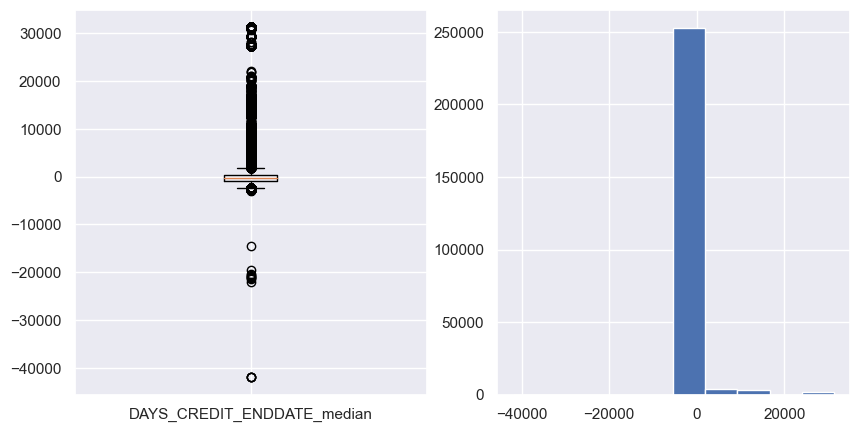

In [94]:
plot_hist_box(numerical_frame, 'DAYS_CREDIT_ENDDATE_median')

Number of outliers : 4118


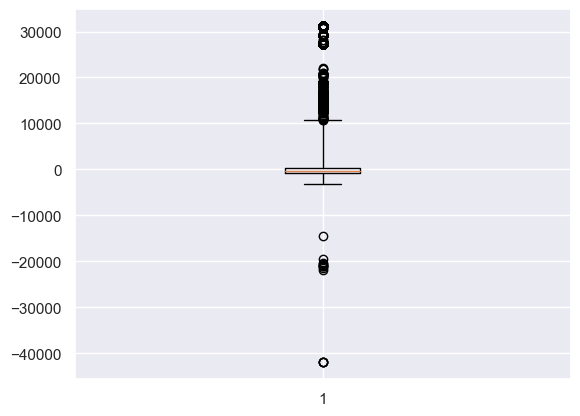

In [98]:
plt.boxplot(numerical_frame['DAYS_CREDIT_ENDDATE_median'].dropna(), whis=10);
numerical_frame['YEARS_CREDIT_ENDDATE_median']=numerical_frame['DAYS_CREDIT_ENDDATE_median']/365
q1, q3, iqr=calc_iqr('DAYS_CREDIT_ENDDATE_median', numerical_frame)
numerical_frame['DAYS_CREDIT_ENDDATE_median_outlier']=0
numerical_frame.loc[(numerical_frame['DAYS_CREDIT_ENDDATE_median']<q1-10*iqr) | 
                    (numerical_frame['DAYS_CREDIT_ENDDATE_median']>q3+10*iqr), 'DAYS_CREDIT_ENDDATE_median_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_CREDIT_ENDDATE_median_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_CREDIT_ENDDATE_median_outlier']==1).sum()))

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

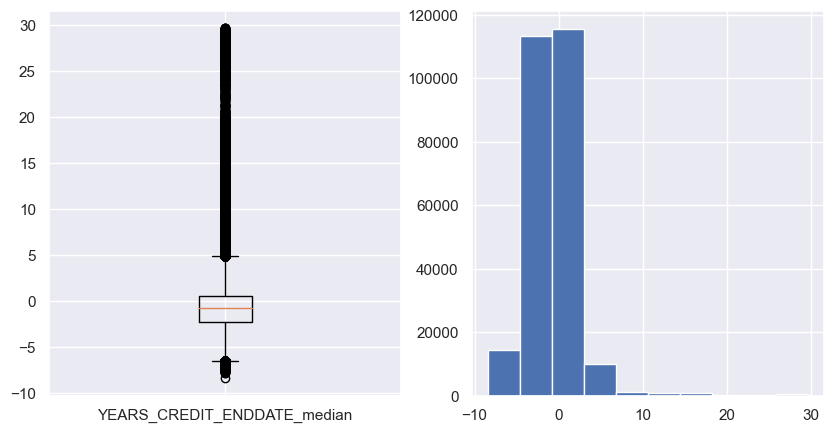

In [99]:
plot_hist_box(good_frame, 'YEARS_CREDIT_ENDDATE_median')

Median of YEARS_CREDIT_ENDDATE_median with target=0 : -0.830137
Median of YEARS_CREDIT_ENDDATE_median with target=1 : -0.194521


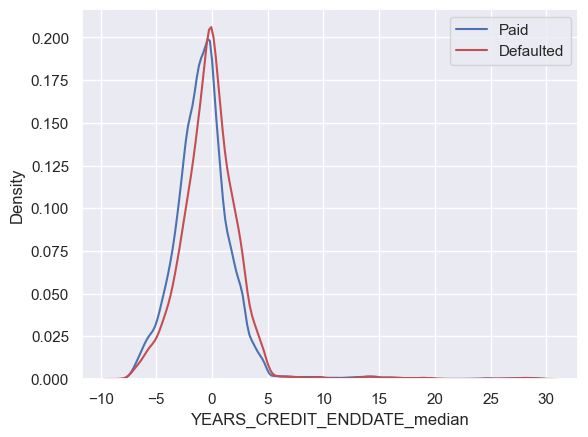

In [100]:
plot_kde_vs_target('YEARS_CREDIT_ENDDATE_median', good_frame)
median_vs_target('YEARS_CREDIT_ENDDATE_median', good_frame)

(-8.42, -3.607]      5.488274
(-3.607, -2.471]     5.490429
(-2.471, -1.718]     5.747489
(-1.718, -1.074]     6.274277
(-1.074, -0.485]     7.081470
(-0.485, 0.0411]     8.435088
(0.0411, 0.779]      9.061953
(0.779, 2.022]      10.450633
(2.022, 29.696]     10.555069
Name: YEARS_CREDIT_ENDDATE_median_binned, dtype: float64


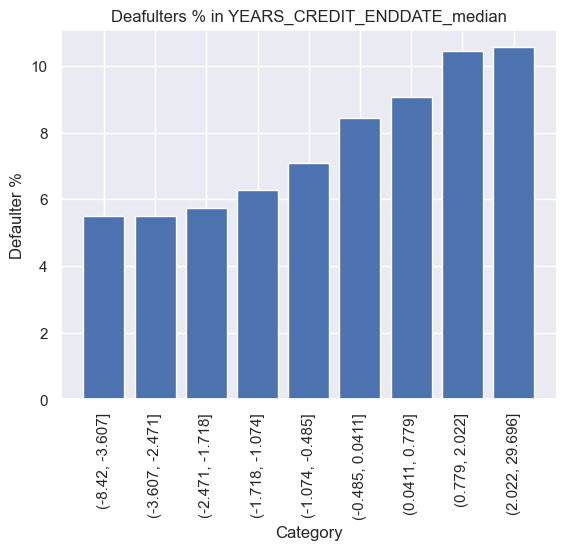

In [101]:
plot_hist_default_pct('YEARS_CREDIT_ENDDATE_median', good_frame, 9)